(20 Mar 2026)

The package depends quite substantially on the `mesh_mask` file being "clean" and in one of the eORCA1 cases this was not the case. The below documents what seems to be wrong, and then patches it up accordingly by writing in some variables from somewhere else.

### <span style="color:red">TODO</span>

* ignoring `fmask` for now, probably imply this from `umask` and `vmask` at some point

### queries:

* Not really sure where the problem comes from, could be `REBUILD_NEMO` being applied to where it is not supposed to (e.g. land suppression with NaNs and getting confused with stitching the tiles together)?
* Could just use the tiled `mesh_mask_0???.nc` files and rely on `xnemogcm` to stitch it together? To try maybe... (may provide some evidence for/against the above)

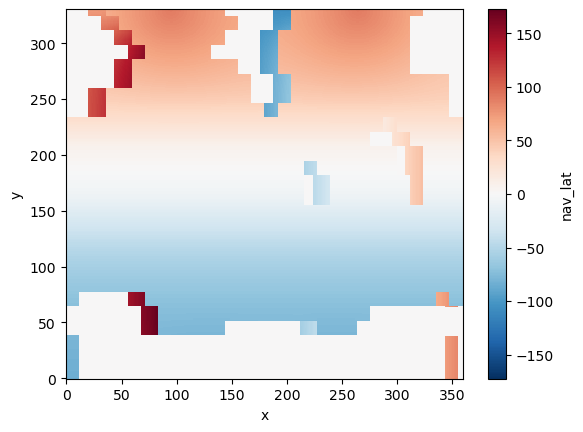

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

data_dir = "/project/miffy/data/users/julian/NEMO/eORCA1_JRA55/"
mesh_mask = xr.open_dataset(data_dir + "mesh_mask.nc")

mesh_mask.nav_lat.plot()

Seems to be some screwy things going on with the land points. These are also in the co-ordinate and metric variables, the latter being potentially more problematic.

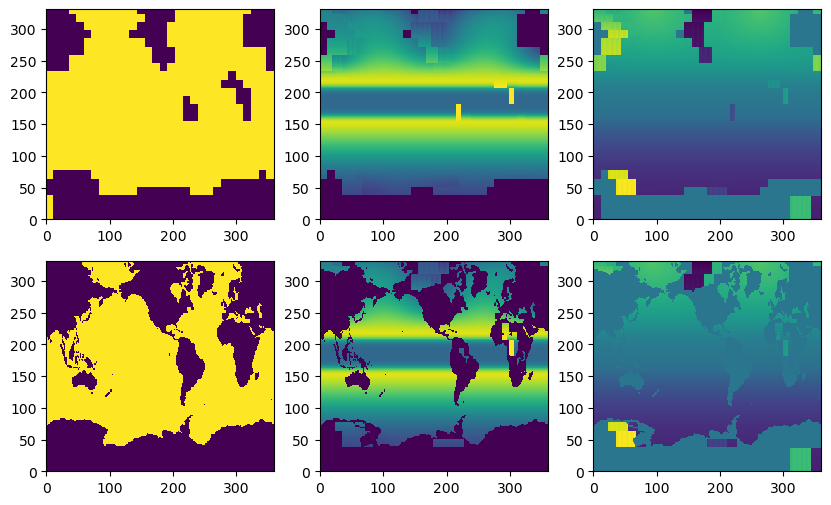

In [2]:
fig, axs = plt.subplots(2, 3, figsize=(10, 6))

axs[0, 0].pcolor(mesh_mask.e3v_0[0, 0, :, :])
axs[0, 1].pcolor(mesh_mask.e2v[0, :, :])
axs[0, 2].pcolor(mesh_mask.gphiv[0, :, :])

axs[1, 0].pcolor(mesh_mask.e3v_0[0, 0, :, :] * mesh_mask.vmask[0, 0, :, :])
axs[1, 1].pcolor(mesh_mask.e2v[0, :, :] * mesh_mask.vmask[0, 0, :, :])
axs[1, 2].pcolor(mesh_mask.gphiv[0, :, :] * mesh_mask.vmask[0, 0, :, :])

Actually, looks like even after masking there are some problematic regions... going to query the masks.

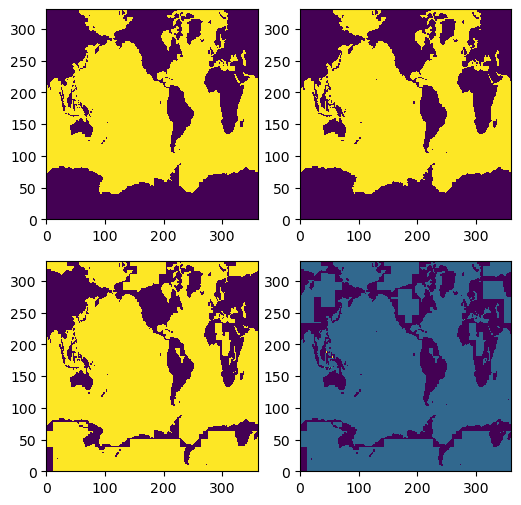

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(6, 6))

axs[0, 0].pcolor(mesh_mask.tmask[0, 0, :, :])
axs[0, 1].pcolor(mesh_mask.umask[0, 0, :, :])
axs[1, 0].pcolor(mesh_mask.vmask[0, 0, :, :])
axs[1, 1].pcolor(mesh_mask.fmask[0, 0, :, :])

Looks like the masks are somewhat screwed up also, which is somewhat annoying. These could be regenerated from the output data probably, because those should really be suppressed to be zero, so we can just query and return a mask value of `1` where the values are identically (or close enough to `0`).

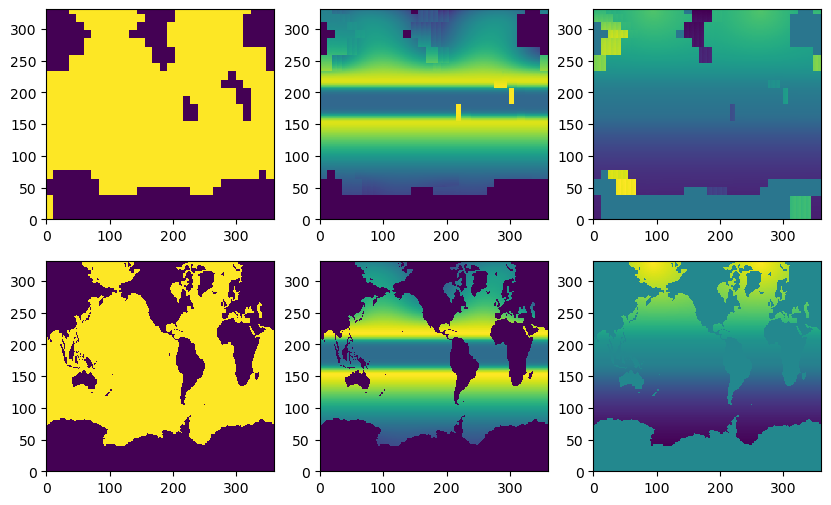

In [4]:
fig, axs = plt.subplots(2, 3, figsize=(10, 6))

axs[0, 0].pcolor(mesh_mask.e3v_0[0, 0, :, :])
axs[0, 1].pcolor(mesh_mask.e2v[0, :, :])
axs[0, 2].pcolor(mesh_mask.gphiv[0, :, :])

axs[1, 0].pcolor(mesh_mask.e3v_0[0, 0, :, :] * mesh_mask.tmask[0, 0, :, :])
axs[1, 1].pcolor(mesh_mask.e2v[0, :, :] * mesh_mask.tmask[0, 0, :, :])
axs[1, 2].pcolor(mesh_mask.gphiv[0, :, :] * mesh_mask.tmask[0, 0, :, :])

number of tmask points with mismatch = 0 (out of 8937000)
number of umask points with mismatch = 211614 (out of 8937000)
number of vmask points with mismatch = 1636812 (out of 8937000)


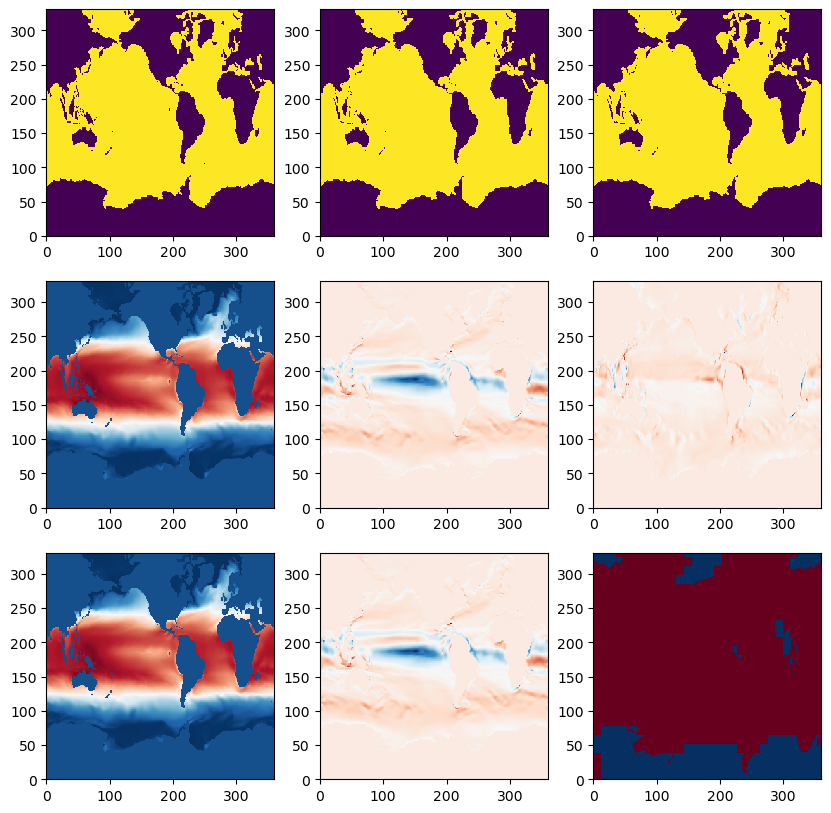

In [5]:
file_T = xr.open_dataset(data_dir + "GEOM/cycle1/eORCA1_1m_grid_T_200001-200001.nc")
file_U = xr.open_dataset(data_dir + "GEOM/cycle1/eORCA1_1m_grid_U_200001-200001.nc")
file_V = xr.open_dataset(data_dir + "GEOM/cycle1/eORCA1_1m_grid_V_200001-200001.nc")

# find where data is not NaN and set it to 1
tmask = np.where(~np.isnan(file_T.thetao_con[0, :, :, :].values), 1, 0)
diff = np.abs((tmask - mesh_mask.tmask[0, :, :, :].values))
print(f"number of tmask points with mismatch = {diff.sum()} (out of {tmask.size})")

umask = np.where(~np.isnan(file_U.uo[0, :, :, :].values), 1, 0)
diff = np.abs((umask - mesh_mask.umask[0, :, :, :].values))
print(f"number of umask points with mismatch = {diff.sum()} (out of {umask.size})")

vmask = np.where(~np.isnan(file_V.vo[0, :, :, :].values), 1, 0)
diff = np.abs((vmask - mesh_mask.vmask[0, :, :, :].values))
print(f"number of vmask points with mismatch = {diff.sum()} (out of {vmask.size})")

# plot variable raw (but with NaNs replaced by something screwy), multiplied with implied mask, and multiplied with "wrong" mask
theta = file_T.thetao_con[0, 0, :, :].values
theta[np.isnan(theta)] = -9999
uo = file_U.uo[0, 0, :, :].values
uo[np.isnan(uo)] = -9999
vo = file_V.vo[0, 0, :, :].values
vo[np.isnan(vo)] = -9999

fig, axs = plt.subplots(3, 3, figsize=(10, 10))

axs[0, 0].pcolor(theta)
axs[0, 1].pcolor(uo)
axs[0, 2].pcolor(uo)

axs[1, 0].pcolor(theta * tmask[0, :, :], cmap="RdBu_r")
axs[1, 1].pcolor(uo * umask[0, :, :], cmap="RdBu_r")
axs[1, 2].pcolor(vo * vmask[0, :, :], cmap="RdBu_r")

axs[2, 0].pcolor(theta * mesh_mask.tmask[0, 0, :, :], cmap="RdBu_r")
axs[2, 1].pcolor(uo * mesh_mask.umask[0, 0, :, :], cmap="RdBu_r")
axs[2, 2].pcolor(vo * mesh_mask.vmask[0, 0, :, :], cmap="RdBu_r")

## overwriting some variables in `mesh_mask.nc`

* actually easier to imbue the original `domain_cfg.nc` file with the relevant mask variables
* substituting the implied `*mask` variables

<span style="color:red">**TODO**</span>: the `fmask` is fudged for the time-being, do it properly from `umask` and `vmask` at some point (double check the NEMO code)

In [6]:
domain_cfg = xr.open_dataset(data_dir + "domain_cfg.nc")
domain_cfg

<xarray.Dataset> Size: 667MB
Dimensions:        (t: 1, y: 331, x: 360, z: 75)
Dimensions without coordinates: t, y, x, z
Data variables: (12/54)
    bathy_metry    (t, y, x) float32 477kB ...
    bottom_level   (t, y, x) int32 477kB ...
    e1f            (t, y, x) float64 953kB ...
    e1t            (t, y, x) float64 953kB ...
    e1u            (t, y, x) float64 953kB ...
    e1v            (t, y, x) float64 953kB ...
    ...             ...
    mask_csgrpemp  (t, y, x) int32 477kB ...
    mask_csgrpglo  (t, y, x) int32 477kB ...
    mask_csgrprnf  (t, y, x) int32 477kB ...
    mask_csrnf     (t, y, x) int32 477kB ...
    mask_csundef   (t, y, x) int32 477kB ...
    mask_opensea   (t, y, x) int32 477kB ...
Attributes:
    DOMAIN_number_total:     1
    DOMAIN_number:           0
    DOMAIN_dimensions_ids:   [1 2]
    DOMAIN_size_global:      [362 332]
    DOMAIN_size_local:       [362 332]
    DOMAIN_position_first:   [1 1]
    DOMAIN_position_last:    [362 332]
    DOMAIN_halo_size_start:  [0 0]
    DOMAIN_halo_size_end:    [0 0]
    DOMAIN_type:             BOX
    history:                 Mon Jun  5 12:41:32 2023: ncks -A mask.nc ORCA1_...
    NCO:                     4.4.7

In [11]:
# for 

In [9]:
domain_cfg["tmask"] = xr.DataArray(tmask[np.newaxis, ...].astype(np.int32),
                                   dims=("t", "z", "y", "x"),
                                   name="tmask"
                                  )
domain_cfg["umask"] = xr.DataArray(umask[np.newaxis, ...].astype(np.int32),
                                   dims=("t", "z", "y", "x"),
                                   name="umask"
                                  )
domain_cfg["vmask"] = xr.DataArray(vmask[np.newaxis, ...].astype(np.int32),
                                   dims=("t", "z", "y", "x"),
                                   name="vmask"
                                  )
### !!!!
domain_cfg["fmask"] = xr.DataArray(tmask[np.newaxis, ...].astype(np.int32), # cheating here !!!
                                   dims=("t", "z", "y", "x"),
                                   name="fmask"
                                  )

domain_cfg.to_netcdf(data_dir + "domain_cfg_cleaned.nc")

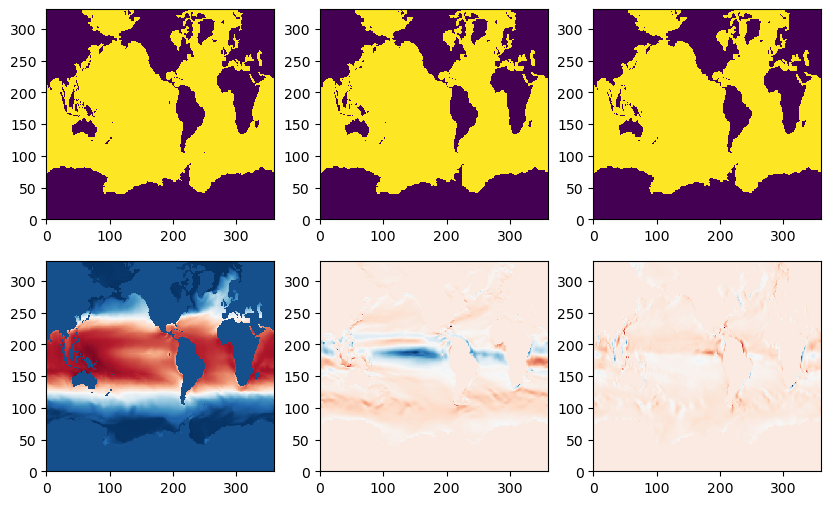

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(10, 6))

axs[0, 0].pcolor(theta)
axs[0, 1].pcolor(uo)
axs[0, 2].pcolor(uo)

axs[1, 0].pcolor(theta * domain_cfg.tmask[0, 0, :, :], cmap="RdBu_r")
axs[1, 1].pcolor(uo * domain_cfg.umask[0, 0, :, :], cmap="RdBu_r")
axs[1, 2].pcolor(vo * domain_cfg.vmask[0, 0, :, :], cmap="RdBu_r")